Manual Outcomes derived from raw data sources

In [1]:
# -----------------------------
# 0. Load data
# -----------------------------
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

BASE = #<<ADD YOUR BASE>>

# Load datasets
file_path_fatigue = BASE + '/BUDDI_PROM_vermoeidheid_export_20250317.csv'
data_proms_fatigue_base = pd.read_csv(file_path_fatigue, sep=';', quotechar='"')
data_proms_fatigue = data_proms_fatigue_base.copy()

file_path_patient_export = BASE + '/BUDDI_export_20250317.csv' 
data_patient_base = pd.read_csv(file_path_patient_export, sep=';', quotechar='"')
data_patient = data_patient_base.copy()

file_path_demographics = BASE + '/BUDDI_export_20250317.csv'
data_demographics_base = pd.read_csv(file_path_demographics, sep=';', quotechar='"')
data_demographics = data_demographics_base.copy()

file_path_proms_angst = BASE + '/BUDDI_PROM_angst_export_20250317.csv' 
data_proms_angst_base = pd.read_csv(file_path_proms_angst, sep=';', quotechar='"')
data_proms_angst = data_proms_angst_base.copy()

file_path_proms_cognitief_functioneren = BASE + '/BUDDI_PROM_cognitief_functioneren_export_20250317.csv' 
data_proms_cognitief_functioneren_base = pd.read_csv(file_path_proms_cognitief_functioneren, sep=';', quotechar='"')
data_proms_cognitief_functioneren = data_proms_cognitief_functioneren_base.copy()

file_path_vineland =  BASE + '/BUDDI_Vineland_export_20250317.csv'
data_vineland_base = pd.read_csv(file_path_vineland, sep=';', quotechar='"')
data_vineland = data_vineland_base.copy()

file_path_proms_depression = BASE + '/BUDDI_PROM_depressieve_klachten_export_20250317.csv'
data_proms_depression_base = pd.read_csv(file_path_proms_depression, sep=';', quotechar='"')
data_proms_depression = data_proms_depression_base.copy()

file_path_srs = BASE + '/BUDDI_SRS_export_20250317.csv'  
file_path_rbs = BASE + '/BUDDI_RBS_export_20250317.csv'  

data_srs_base = pd.read_csv(file_path_srs, sep=';', quotechar='"')
data_rbs_base = pd.read_csv(file_path_rbs, sep=';', quotechar='"')
data_srs = data_srs_base.copy()
data_rbs = data_rbs_base.copy()

file_path_neuropsychiatric_history =  BASE + '/BUDDI_Neuropsychiatric_history_export_20250317.csv'
data_neuropsychiatric_history_base = pd.read_csv(file_path_neuropsychiatric_history, sep=';', quotechar='"')
data_neuropsychiatric_history = data_neuropsychiatric_history_base.copy()


SyntaxError: invalid syntax (1198946223.py, line 8)

Development Questions

In [ ]:
# -----------------------------
# . 1. How many data sources are administered?
# -----------------------------

print(f"FHIR = 11, FHIR No Snomed = 11, raw = 9")


FHIR = 11, FHIR No Snomed = 11, raw = 10


In [ ]:
# -----------------------------
# 2. What is the Vineland coping skills V-score for patient BU044?
# -----------------------------

# -----------------------------
# Data (fresh copies)
# -----------------------------
data_vineland = data_vineland_base.copy()

# Retrieve VL_soc_AV_V_2 for BU044
def get_vl_soc_av_v2(data_vineland, participant_id):
    try:
        result = data_vineland.loc[data_vineland['Participant Id'] == participant_id, 'VL_soc_AV_V_2']
        if not result.empty:
            return result.values[0]
        else:
            return None
    except Exception as e:
        print(f"Failed to retrieve VL_soc_AV_V_2: {e}")
        return None

participant_id = 'BU044'
vl_soc_av_v2 = get_vl_soc_av_v2(data_vineland, participant_id)

if vl_soc_av_v2 is not None:
    print(f"VL_soc_AV_V_2 for {participant_id}: {vl_soc_av_v2}")
else:
    print(f"No data found for {participant_id}.")


VL_soc_AV_V_2 for BU044: 13.0


In [ ]:
# -----------------------------
# 3. What is the standard deviation of the V-score across all patients for the Vineland receptive communication domain?
# -----------------------------

# -----------------------------
# Data (fresh copies)
# -----------------------------
data_vineland = data_vineland_base.copy()

# Extract columns that start with 'VL_com_RT_' (social adaptive scores)
com_RT_columns = [col for col in data_vineland.columns if col.startswith('VL_com_RT_')]

# Filter rows with complete data for social adaptive scores
com_RT_data = data_vineland[com_RT_columns].dropna()

# Calculate standard deviation for each social adaptive score column
standard_deviation = com_RT_data.std()
mean = com_RT_data.mean()

# Display the results
print("Standard deviation of the cohort's Vineland com RT  scores:")
print(standard_deviation)
print("Mean of the cohort's Vineland com RT scores:")
print(mean)


Standard deviation of the cohort's Vineland com RT  scores:
VL_com_RT_ruw_2     6.769381
VL_com_RT_V_2      13.214526
VL_com_RT_age_2     3.162577
VL_com_RT_gsv_2    12.074059
VL_com_RT_an_2      0.843739
dtype: float64
Mean of the cohort's Vineland com RT scores:
VL_com_RT_ruw_2     64.313433
VL_com_RT_V_2        8.731343
VL_com_RT_age_2      4.129075
VL_com_RT_gsv_2    106.626866
VL_com_RT_an_2       3.014925
dtype: float64


In [ ]:
# -----------------------------
# 4. How many children have a Vineland raw communication scale of <85, how many have a PROM depressieve klachten of <40), and how many have both?
# -----------------------------

# -----------------------------
# Data (fresh copies)
# -----------------------------
data_vineland = data_vineland_base.copy()
data_proms_depression = data_proms_depression_base.copy()

# Filter for relevant columns and unique patients
vineland_scores = data_vineland[['Participant Id', 'VL_com_RT_ruw_2']].drop_duplicates(subset='Participant Id')
prom_depression_scores = data_proms_depression[['Participant Id', 'PROM_depressieve_klachten_Tscore']]

# Filter for children with Vineland communication scale < 15
vineland_below_85 = vineland_scores[vineland_scores['VL_com_RT_ruw_2'] < 85]

# Filter for children with PROM depressieve klachten < 40
prom_depression_below_40 = prom_depression_scores[prom_depression_scores['PROM_depressieve_klachten_Tscore'] < 40].drop_duplicates(subset='Participant Id')
print(len(prom_depression_below_40))

# Merge datasets on Participant Id to find children meeting both criteria
vineland_depression_merged_data = pd.merge(
    vineland_below_85,
    prom_depression_below_40,
    on='Participant Id',
    how='inner'
)

# Count the number of children meeting each criterion
num_vineland_below_85 = len(vineland_below_85)
num_prom_depression_below_40 = len(prom_depression_below_40)
num_unique_children = len(vineland_depression_merged_data)

print(f"Number of children with Vineland communication scale < 85: {num_vineland_below_85}")
print(f"Number of children with PROM depressieve klachten < 40: {num_prom_depression_below_40}")
print(f"Number of children meeting both criteria: {num_unique_children}")


52
Number of children with Vineland communication scale < 85: 67
Number of children with PROM depressieve klachten < 40: 52
Number of children meeting both criteria: 28


In [ ]:
# -----------------------------
# 4b. How many children have a Vineland raw communication scale of <85, how many have a PROM depressieve klachten of <40), and how many have both?
# -----------------------------

# -----------------------------
# Data (fresh copies)
# -----------------------------
data_vineland = data_vineland_base.copy()
data_proms_depression = data_proms_depression_base.copy()

# Filter for relevant columns and unique patients
vineland_scores = data_vineland[['Participant Id', 'VL_com_RT_ruw_2']].drop_duplicates(subset='Participant Id')
prom_depression_scores = data_proms_depression[['Participant Id', 'PROM_depressieve_klachten_Tscore']]

# Filter for children with Vineland communication scale < 85
vineland_below_85 = vineland_scores[vineland_scores['VL_com_RT_ruw_2'] < 85]

# Filter for children with PROM depressieve klachten < 40
prom_depression_below_40 = prom_depression_scores[prom_depression_scores['PROM_depressieve_klachten_Tscore'] < 40].drop_duplicates(subset='Participant Id')

# Merge datasets on Participant Id to find children meeting both criteria
vineland_depression_merged_data = pd.merge(
    vineland_below_85,
    prom_depression_below_40,
    on='Participant Id',
    how='inner'
)

# Count the number of children meeting each criterion
num_vineland_below_85 = len(vineland_below_85)
num_prom_depression_below_40 = len(prom_depression_below_40)
num_unique_children = len(vineland_depression_merged_data)

print(f"Number of children with Vineland communication scale < 85: {num_vineland_below_85}")
print(f"Number of children with PROM depressieve klachten < 40: {num_prom_depression_below_40}")
print(f"Number of children meeting both criteria: {num_unique_children}")


Number of children with Vineland communication scale < 15: 67
Number of children with PROM depressieve klachten < 40: 52
Number of children with both conditions: 28


Number of unique children with  Vineland receptive V-score scale: 53
Number of unique children with SRS > 70: 107
Number of unique children with RBS > 0: 116
Number of unique children with normal Vineland communication scale and SRS > 70 or RBS > 0: 50


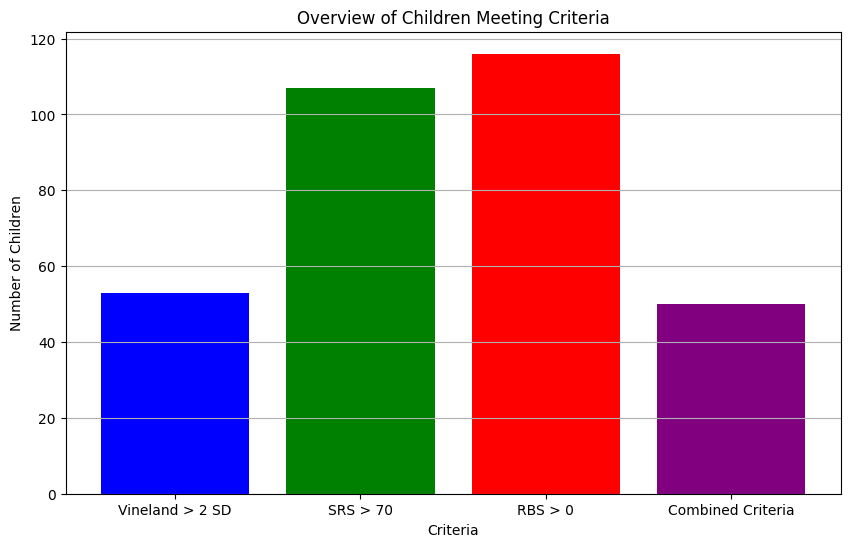

Probability that a child with normal Vineland social adaptive score also meets SRS > 70 or RBS > 0 criteria: 94.33962264150944%


In [ ]:
# -----------------------------
# 5. If a patient has a Vineland social adaptive V-score between 9-21, what is the chance that he/she scores >70 on SRS t-score  and/or >0 on the RBS total score?
# -----------------------------

# -----------------------------
# Data (fresh copies)
# -----------------------------
data_vineland = data_vineland_base.copy()
data_srs = data_srs_base.copy()
data_rbs = data_rbs_base.copy()

# Filter for children with Vineland social adaptive V-score between 9-21
vineland_normal = data_vineland[
    (data_vineland['VL_soc_AV_V_2'] >= 9) & (data_vineland['VL_soc_AV_V_2'] <= 21)
][['Participant Id', 'VL_soc_AV_V_2']]

num_unique_vineland_normal = len(vineland_normal['Participant Id'].unique())
print(f"Number of unique children with normal Vineland communication scale: {num_unique_vineland_normal}")


# Filter for children with SRS_total_tscore > 70
srs_above_70 = data_srs[data_srs['SRS_total_tscore'] > 70][['Participant Id', 'SRS_total_tscore']]

num_unique_srs_above_70 = len(srs_above_70['Participant Id'].unique())
print(f"Number of unique children with SRS > 70: {num_unique_srs_above_70}")


# Filter for children with RBS_total_score > 0
rbs_above_0 = data_rbs[data_rbs['RBS_total_score'] > 0][['Participant Id', 'RBS_total_score']]

num_unique_rbs_above_0 = len(rbs_above_0['Participant Id'].unique())
print(f"Number of unique children with RBS > 0: {num_unique_rbs_above_0}")


# Merge datasets to find children meeting any criteria
merged_srs_rbs = pd.concat([srs_above_70, rbs_above_0]).drop_duplicates(subset='Participant Id')
merged_srs_rbs_vineland_data = pd.merge(vineland_normal, merged_srs_rbs, on='Participant Id', how='inner')

# Count unique Participant Ids meeting all criteria
num_unique_children_vineland_srs_rbs = len(merged_srs_rbs_vineland_data['Participant Id'].unique())

print(f"Number of unique children with normal Vineland communication scale and SRS > 70 or RBS > 0: {num_unique_children_vineland_srs_rbs}")

# Prepare data for visualization
categories = ['Vineland > 2 SD', 'SRS > 70', 'RBS > 0', 'Combined Criteria']
values = [num_unique_vineland_normal, num_unique_srs_above_70, num_unique_rbs_above_0, num_unique_children_vineland_srs_rbs]

# Plot the graph
plt.figure(figsize=(10, 6))
plt.bar(categories, values, color=['blue', 'green', 'red', 'purple'])
plt.title('Overview of Children Meeting Criteria')
plt.xlabel('Criteria')
plt.ylabel('Number of Children')
plt.grid(axis='y')
plt.show()

#Chance 
probability = (num_unique_children_vineland_srs_rbs / num_unique_vineland_normal) * 100
print(f"Probability that a child with normal Vineland social adaptive score also meets SRS > 70 or RBS > 0 criteria: {probability}%")


PROM questions

In [ ]:
# -----------------------------
# 6. How many different PROM questionnaires are recorded in the dataset?
# -----------------------------

print(f"There are 4 different PROMs in the dataset")


There are 4 different PROMs in the dataset


In [ ]:
# -----------------------------
# 7. When did BU002 fill his/her last PROM cognitive questionnaire?
# -----------------------------

import pandas as pd

# -----------------------------
# Data (fresh copies)
# -----------------------------
data_proms_cognitief_functioneren = data_proms_cognitief_functioneren_base.copy()

# Use export-based PROM cognitive dataset
df = data_proms_cognitief_functioneren.copy()

# Filter for BU002
bu002_data = df[df['Participant Id'] == 'BU002'].copy()

# Convert the date column to datetime (day-first format)
bu002_data['PROM_cognitief_functioneren_date'] = pd.to_datetime(
    bu002_data['PROM_cognitief_functioneren_date'], dayfirst=True, errors='coerce'
)

# Find the most recent date
last_fill_date = bu002_data['PROM_cognitief_functioneren_date'].max()

if pd.notnull(last_fill_date):
    print(f"BU002 last filled the PROM cognitive questionnaire on: {last_fill_date.strftime('%d %B %Y')}")
else:
    print("No valid PROM cognitive questionnaire date found for BU002.")


BU002 last filled the PROM cognitive questionnaire on: 28 February 2022


/var/folders/y7/z7_l2gg127j891pr5w15970r0000gn/T/ipykernel_82575/114387705.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bu002_data['PROM_cognitief_functioneren_date'] = pd.to_datetime(


In [ ]:
# -----------------------------
# 8. How many patients have PROMs depressive complaints  T-score less than 40?
# -----------------------------

# -----------------------------
# Data (fresh copies)
# -----------------------------
data_proms_depression = data_proms_depression_base.copy()

# Count patients with T-score less than 40
def count_low_t_scores(data_proms_depression):
    try:
        # Filter for T-scores less than 40
        low_t_scores = data_proms_depression[data_proms_depression['PROM_depressieve_klachten_Tscore'] < 40]
        
        # Count unique participants
        num_unique_participants_low_depression = len(low_t_scores['Participant Id'].unique())
        
        return num_unique_participants_low_depression
    except Exception as e:
        print(f"Failed to count low T-scores: {e}")
        return None

# Main function to execute
def main():
    if data_proms_depression is not None:
        num_low_t_scores = count_low_t_scores(data_proms_depression)
        if num_low_t_scores is not None:
            print(f"Number of patients with PROMs depressive complaints T-score less than 40: {num_low_t_scores}")
        else:
            print("Failed to count patients.")
    else:
        print("Failed to load dataset.")

if __name__ == "__main__":
    main()


Number of patients with PROMs depressive complaints T-score less than 40: 52


In [ ]:
# -----------------------------
# 9. What percentage of children do not have a PROMs depressive complaints questionnaire filled out and are older than 15 years old (on July 29, 2025)?
# -----------------------------

import pandas as pd
from datetime import datetime

# -----------------------------
# Data (fresh copies)
# -----------------------------
data_demographics = data_demographics_base.copy()
data_proms_depression = data_proms_depression_base.copy()

# Prepare demographics: derive age on reference date
dem = data_demographics.dropna(subset=['dem_birth_month', 'dem_birth_year']).copy()
dem['dem_birth_month'] = pd.to_numeric(dem['dem_birth_month'], errors='coerce')
dem['dem_birth_year'] = pd.to_numeric(dem['dem_birth_year'], errors='coerce')

dem['birth_date'] = pd.to_datetime(
    dem['dem_birth_year'].astype('Int64').astype(str) + '-' +
    dem['dem_birth_month'].astype('Int64').astype(str).str.zfill(2) + '-01',
    errors='coerce'
)

reference_date = datetime(2025, 7, 29)
dem['age_on_reference'] = (reference_date - dem['birth_date']).dt.days // 365

# Filter patients older than 15
patients_over_15 = dem[dem['age_on_reference'] > 15].copy()
over_15_ids = patients_over_15['Participant Id'].dropna().unique()

# Identify children with any PROM depressieve klachten record
filled_proms_ids = data_proms_depression['Participant Id'].dropna().unique()
over_15_with_proms = [pid for pid in over_15_ids if pid in filled_proms_ids]

# Totals and percentages
total_patients = dem['Participant Id'].nunique()
total_over_15 = len(over_15_ids)
filled_count = len(over_15_with_proms)

percentage_over_15 = (total_over_15 / total_patients) * 100 if total_patients > 0 else 0
percentage_filled = (filled_count / total_over_15) * 100 if total_over_15 > 0 else 0

print(f"Total number of patients: {total_patients}")
print(f"Number of patients older than 15 years: {total_over_15}")
print(f"Percentage of patients older than 15 years: {percentage_over_15:.2f}%")
print(f"Patients older than 15 with PROMs depressive complaints questionnaire: {filled_count}")
print(f"Percentage of patients older than 15 with questionnaire: {percentage_filled:.2f}%")


Total number of patients: 119
Number of patients older than 15 years: 66
Percentage of patients older than 15 years: 55.46%
Patients older than 15 with PROMs depressive complaints questionnaire: 66
Percentage of patients older than 15 with questionnaire: 100.00%


LAB related questions

In [ ]:
# -----------------------------
# 10. If the Vineland communication scale (VL_com_RT_ruw_2) is less than 85, what is the chance of decrease the PROMs depressive complaints T-score with 10 over a period of 6 months since first PROMs depressive complaints?
# -----------------------------

# -----------------------------
# Data (fresh copies)
# -----------------------------
data_proms_depression = data_proms_depression_base.copy()

import pandas as pd
import numpy as np

# Load data 
vineland = data_vinelandPROMs.copy() 
proms = data_proms_depression.copy()

# Standardize column names for easier access
vineland.columns = vineland.columns.str.strip()
proms.columns = proms.columns.str.strip()

# Prepare Vineland: select patients with VL_com_RT_ruw_2 < 85
vineland['VL_com_RT_ruw_2'] = pd.to_numeric(vineland['VL_com_RT_ruw_2'], errors='coerce')
vineland_sub = vineland[vineland['VL_com_RT_ruw_2'] < 85][['Participant Id', 'VL_com_RT_ruw_2']].drop_duplicates('Participant Id')

# Prepare PROMs: parse dates and T-scores
proms['PROM_depressieve_klachten_date'] = pd.to_datetime(proms['PROM_depressieve_klachten_date'], dayfirst=True, errors='coerce')
proms['PROM_depressieve_klachten_Tscore'] = pd.to_numeric(proms['PROM_depressieve_klachten_Tscore'], errors='coerce')

# Merge to get only patients with VL_com_RT_ruw_2 < 85
merged = proms.merge(vineland_sub, left_on='Participant Id', right_on='Participant Id', how='inner')

# For each patient, find baseline and first follow-up >= 183 days later
results = []
for pid, group in merged.groupby('Participant Id'):
    group = group.sort_values('PROM_depressieve_klachten_date')
    if group.empty:
        continue
    baseline = group.iloc[0]
    baseline_date = baseline['PROM_depressieve_klachten_date']
    baseline_score = baseline['PROM_depressieve_klachten_Tscore']
    # Find first follow-up at least 183 days later
    followups = group[group['PROM_depressieve_klachten_date'] >= baseline_date + pd.Timedelta(days=183)]
    if followups.empty:
        continue
    followup = followups.iloc[0]
    followup_score = followup['PROM_depressieve_klachten_Tscore']
    delta = followup_score - baseline_score
    improved = delta >= -10
    results.append({'Participant Id': pid, 'baseline_score': baseline_score, 'followup_score': followup_score, 'delta': delta, 'improved': improved})

results_df = pd.DataFrame(results)

# Calculate chance of improvement
n = len(results_df)
n_improved = results_df['improved'].sum()
chance = n_improved / n if n > 0 else np.nan

print(f"Number of patients with VL_com_RT_ruw_2 < 85 and PROM follow-up: {n}")
print(f"Number improved by at least 10 points: {n_improved}")
print(f"Chance of improvement: {chance:.1%}")

# Optional: 95% Wilson confidence interval
from math import sqrt
z = 1.96
phat = chance
denom = 1 + z**2/n if n > 0 else np.nan
centre = (phat + z**2/(2*n)) / denom if n > 0 else np.nan
margin = z*sqrt(phat*(1-phat)/n + z**2/(4*n**2))/denom if n > 0 else np.nan
ci_low, ci_high = max(0, centre - margin), min(1, centre + margin) if n > 0 else (np.nan, np.nan)
print(f"95% CI: {ci_low:.1%} – {ci_high:.1%}")


Number of patients with VL_com_RT_ruw_2 < 85 and PROM follow-up: 60
Number improved by at least 10 points: 49
Chance of improvement: 81.7%
95% CI: 70.1% – 89.4%


In [ ]:
# -----------------------------
# 11. Which data source contains the most amount of information (in terms of rows)?
# -----------------------------

# -----------------------------
# Data (fresh copies)
# -----------------------------
data_proms_fatigue = data_proms_fatigue_base.copy()
data_patient = data_patient_base.copy()
data_proms_angst = data_proms_angst_base.copy()
data_proms_cognitief_functioneren = data_proms_cognitief_functioneren_base.copy()
data_vineland = data_vineland_base.copy()
data_proms_depression = data_proms_depression_base.copy()
data_srs = data_srs_base.copy()
data_rbs = data_rbs_base.copy()
data_neuropsychiatric_history = data_neuropsychiatric_history_base.copy()

dataframes = {
    "patient_df": data_patient,
    "proms_angst_df": data_proms_angst,
    "proms_depressieve_klachten_df": data_proms_depression,
    "proms_cognitief_functioneren_df": data_proms_cognitief_functioneren,
    "proms_vermoeidheid_df": data_proms_fatigue,
    "rbs_df": data_rbs,
    "lab_df": data_proms_fatigue,
    "srs_df": data_srs,
    "vineland_df": data_vineland,
    "neuropsychiatric_history_df": data_neuropsychiatric_history
}

# Function to calculate information content
def calculate_info_content(df):
    return df.shape[0] * df.shape[1]

# Calculate information content for each data source
info_content = {name: calculate_info_content(df) for name, df in dataframes.items()}

# Find the data source with the most information
most_informative_source = max(info_content, key=info_content.get)

print(f"The data source with the most information is: {most_informative_source}")
print(f"Information content: {info_content[most_informative_source]}")


The data source with the most information is: patient_df
Information content: 114835


In [ ]:
# -----------------------------
# 12. How many times did patient BU001 have his/her potassium measured
# -----------------------------
#Note: Make sure to check if the patient has a potassium measurement in the urine

# -----------------------------
# Data (fresh copies)
# -----------------------------
data_patient = data_patient_base.copy()

# Filter rows for patient BU001
patient = 'BU001'
patient_data = data_patient[data_patient['Participant Id'] == patient]
    
 # Columns related to potassium measurements (baseline and follow-ups)
potassium_columns = [col for col in patient_data.columns if 'lab_k_' in col]
print(potassium_columns)
    
# Count non-null values (potassium measurements) for BU001
potassium_measurements_count = patient_data[potassium_columns].notnull().sum().sum()

# Extract the columns where potassium was measured for patient BU001
potassium_measurements = patient_data[potassium_columns].notnull()

# Find the specific columns (measurements) where potassium was measured
measured_columns = potassium_measurements.columns[potassium_measurements.any()].tolist()
    
print(f"Patient {patient} had their potassium measured {potassium_measurements_count} times, of which 1 in the urine.")
print(f"His/her Potassium was measured at the following moments: {measured_columns}")


Patient BU001 had their potassium measured 6 times, of which 1 in the urine.
His/her Potassium was measured at the following moments: ['lab_k_baseline', 'lab_k_urine_baseline', 'lab_k_d14', 'lab_k_d28', 'lab_k_d56', 'lab_k_d91']


In [ ]:
# -----------------------------
# 13. What percentage of patients show Kalium measured of less than 3.5 mml/l at any point in time?
# -----------------------------

import pandas as pd

# -----------------------------
# Data (fresh copies)
# -----------------------------
data_patient = data_patient_base.copy()

# Use export-based lab columns in the patient export
patient_df = data_patient.drop_duplicates(subset='Participant Id').copy()

# Potassium measurements (baseline + follow-ups)
potassium_columns = [col for col in patient_df.columns if 'lab_k_' in col]

# Convert to numeric (handles commas as decimal separators)
k_df = patient_df[potassium_columns].astype(str).apply(lambda col: col.str.replace(',', '.', regex=False))
k_df = k_df.apply(pd.to_numeric, errors='coerce')

# Patients with any potassium < 3.5
has_low_kalium = (k_df < 3.5).any(axis=1)
patients_with_low_kalium = patient_df.loc[has_low_kalium, 'Participant Id'].dropna().unique()

total_patients = patient_df['Participant Id'].nunique()
num_low_kalium = len(patients_with_low_kalium)
percentage_low_kalium = (num_low_kalium / total_patients) * 100 if total_patients > 0 else 0

print(f"Percentage of patients with Kalium < 3.5 mmol/L at any time: {percentage_low_kalium:.2f}%")
print("\nPatients with low potassium:")
print(patients_with_low_kalium)


Percentage of patients with Kalium < 3.5 mmol/L at any time: 52.94%

Patients with low potassium:
['BU001' 'BU005' 'BU006' 'BU008' 'BU015' 'BU016' 'BU018' 'BU030' 'BU034'
 'BU081' 'BU082' 'BU083' 'BU085' 'BU093' 'BU094' 'BU099' 'BU107' 'BU108'
 'BU109' 'BU111' 'BU112' 'BU113' 'BU115' 'BU116' 'BU117' 'BU118' 'BU120'
 'BU121' 'BU124' 'BU126' 'BU127' 'BU128' 'BU130' 'BU146' 'BU147' 'BU148'
 'BU149' 'BU150' 'BU151' 'BU152' 'BU155' 'BU158' 'BU159' 'BU161' 'BU162'
 'BU163' 'BU164' 'BU165' 'BU169' 'BU170' 'BU172' 'BU174' 'BU175' 'BU177'
 'BU178' 'BU179' 'BU180' 'BU181' 'BU182' 'BU184' 'BU186' 'BU187' 'BU191']


/var/folders/y7/z7_l2gg127j891pr5w15970r0000gn/T/ipykernel_5078/1352673301.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  low_kalium_df['patient_id'] = low_kalium_df['subject.reference'].str.replace('Patient/', '', regex=False)


In [2]:
# -----------------------------
# 14. What percentage of children has Kalium measured of less than 3.5 mml/l at any point in time are below 15 yrs?
# -----------------------------

import pandas as pd

# -----------------------------
# Data (fresh copies)
# -----------------------------
data_patient = data_patient_base.copy()
data_demographics = data_demographics_base.copy()

# --- Identify patients with low potassium (export-based lab columns) ---
patient_df = data_patient.drop_duplicates(subset='Participant Id').copy()
potassium_columns = [col for col in patient_df.columns if 'lab_k_' in col]

k_df = patient_df[potassium_columns].astype(str).apply(lambda col: col.str.replace(',', '.', regex=False))
k_df = k_df.apply(pd.to_numeric, errors='coerce')

has_low_kalium = (k_df < 3.5).any(axis=1)
patients_with_low_kalium = set(patient_df.loc[has_low_kalium, 'Participant Id'].dropna().unique())

# --- Calculate age as of 2025-07-29 using demographics birth month/year ---
dem = data_demographics.dropna(subset=['dem_birth_month', 'dem_birth_year']).copy()
dem['dem_birth_month'] = pd.to_numeric(dem['dem_birth_month'], errors='coerce')
dem['dem_birth_year'] = pd.to_numeric(dem['dem_birth_year'], errors='coerce')

dem['birth_date'] = pd.to_datetime(
    dem['dem_birth_year'].astype('Int64').astype(str) + '-' +
    dem['dem_birth_month'].astype('Int64').astype(str).str.zfill(2) + '-01',
    errors='coerce'
)

today = pd.Timestamp("2025-07-29")
dem['age'] = (today - dem['birth_date']).dt.days // 365

low_kalium_patients_df = dem[dem['Participant Id'].isin(patients_with_low_kalium)].copy()
low_kalium_patients_df = low_kalium_patients_df.dropna(subset=['age'])

under_15_df = low_kalium_patients_df[low_kalium_patients_df['age'] < 15].copy()

total_low_kalium_patients = low_kalium_patients_df['Participant Id'].nunique()
under_15_count = under_15_df['Participant Id'].nunique()

percentage_under_15 = (under_15_count / total_low_kalium_patients) * 100 if total_low_kalium_patients > 0 else 0

print("Patients with Kalium < 3.5 mmol/L who are under 15 years old:")
print(under_15_df[['Participant Id', 'dem_gender', 'birth_date', 'age']])

print(f"\nTotal patients with low potassium: {total_low_kalium_patients}")
print(f"Number of those under 15: {under_15_count}")
print(f"Percentage of low potassium patients who are under 15: {percentage_under_15:.2f}%")


NameError: name 'data_patient_base' is not defined

      author.display      author.reference             authored  \
0             Father  RelatedPerson/Father  2021-03-18T00:00:00   
1             Father  RelatedPerson/Father  2021-03-18T00:00:00   
2             Father  RelatedPerson/Father  2021-03-18T00:00:00   
3             Father  RelatedPerson/Father  2021-03-18T00:00:00   
4             Father  RelatedPerson/Father  2021-03-18T00:00:00   
...              ...                   ...                  ...   
37898         Mother  RelatedPerson/Mother  2023-05-01T00:00:00   
37899         Mother  RelatedPerson/Mother  2023-05-01T00:00:00   
37900         Mother  RelatedPerson/Mother  2023-05-01T00:00:00   
37901         Mother  RelatedPerson/Mother  2023-05-01T00:00:00   
37902         Mother  RelatedPerson/Mother  2023-05-01T00:00:00   

      item.item.answer.valueDateTime  item.item.answer.valueDecimal  \
0                                NaN                            NaN   
1                                NaN                 

/var/folders/y7/z7_l2gg127j891pr5w15970r0000gn/T/ipykernel_2081/781653545.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prom_tscore_df['PatientID'] = prom_df['subject.reference'].str.extract(r'Patient/(BU\d+)', expand=False)


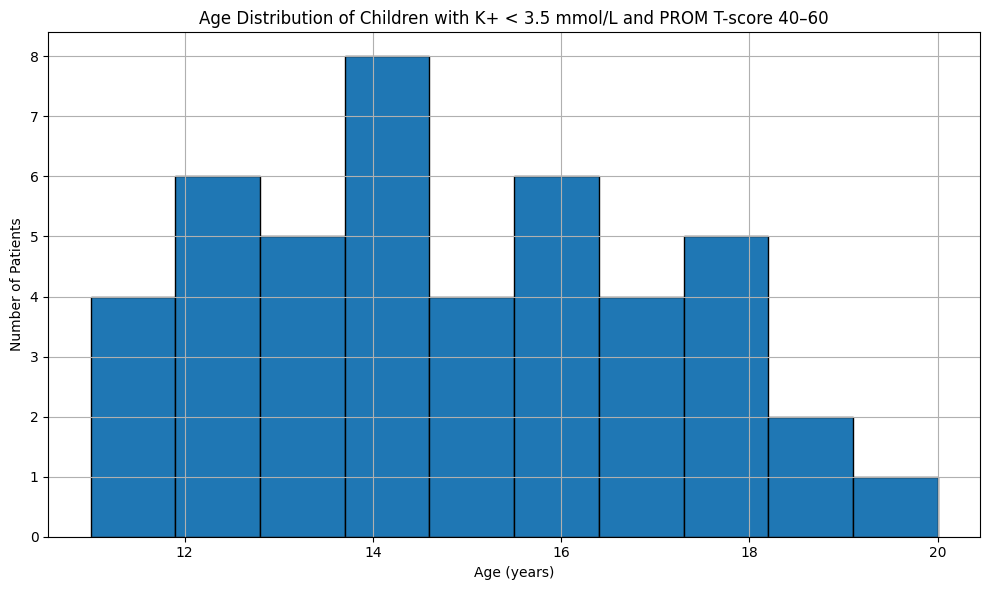

Summary Statistics of Age:
count    45.000000
mean     14.777778
std       2.466953
min      11.000000
25%      13.000000
50%      14.000000
75%      17.000000
max      20.000000
Name: age, dtype: float64
11 = 4
12 = 6
13 = 5
14 = 8
15 = 4
16 = 6
17 = 4
18 = 5
19 = 2
20 = 1


In [ ]:
# -----------------------------
# 15. What is the age distribution of children with Kalium measured smaller than 3.5 mml/l and a lower/higher PROM baseline fatigue score (<T40 en >T60)?
# -----------------------------

import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Data (fresh copies)
# -----------------------------
data_patient = data_patient_base.copy()
data_demographics = data_demographics_base.copy()
data_proms_fatigue = data_proms_fatigue_base.copy()

# --- Identify patients with low potassium (export-based lab columns) ---
patient_df = data_patient.drop_duplicates(subset='Participant Id').copy()
potassium_columns = [col for col in patient_df.columns if 'lab_k_' in col]

k_df = patient_df[potassium_columns].astype(str).apply(lambda col: col.str.replace(',', '.', regex=False))
k_df = k_df.apply(pd.to_numeric, errors='coerce')

has_low_kalium = (k_df < 3.5).any(axis=1)
potassium_patients = patient_df.loc[has_low_kalium, ['Participant Id']].rename(columns={'Participant Id': 'PatientID'}).drop_duplicates()

# --- Clean PROM fatigue data ---
proms = data_proms_fatigue.copy()
print(proms)

proms['PROM_vermoeidheid_Tscore'] = pd.to_numeric(proms['PROM_vermoeidheid_Tscore'], errors='coerce')
prom_tscore_df = proms[
    (proms['PROM_vermoeidheid_Tscore'] >= 40) &
    (proms['PROM_vermoeidheid_Tscore'] <= 60)
].copy()

prom_tscore_df['PatientID'] = prom_tscore_df['Participant Id']
print(prom_tscore_df)

prom_patients = prom_tscore_df[['PatientID']].drop_duplicates()

# --- Merge potassium and PROM data ---
merged_patients_df = pd.merge(potassium_patients, prom_patients, on='PatientID', how='inner').drop_duplicates()

print(f"Number of patients with low potassium and PROM T-score in range: {len(merged_patients_df)}")
print("Sample PatientIDs:", merged_patients_df['PatientID'].unique())

# --- Derive age from demographics birth month/year ---
dem = data_demographics.dropna(subset=['dem_birth_month', 'dem_birth_year']).copy()
dem['dem_birth_month'] = pd.to_numeric(dem['dem_birth_month'], errors='coerce')
dem['dem_birth_year'] = pd.to_numeric(dem['dem_birth_year'], errors='coerce')

dem['birth_date'] = pd.to_datetime(
    dem['dem_birth_year'].astype('Int64').astype(str) + '-' +
    dem['dem_birth_month'].astype('Int64').astype(str).str.zfill(2) + '-01',
    errors='coerce'
)

today = pd.Timestamp("2025-07-29")
dem['age'] = (today - dem['birth_date']).dt.days // 365

final_df = pd.merge(
    merged_patients_df,
    dem[['Participant Id', 'age']],
    left_on='PatientID',
    right_on='Participant Id',
    how='left'
)

final_df = final_df.dropna(subset=['age'])

# --- Plot age distribution ---
plt.figure(figsize=(10, 6))
plt.hist(final_df['age'], bins=10, edgecolor='black')
plt.title('Age Distribution of Children with K+ < 3.5 mmol/L and PROM T-score 40–60')
plt.xlabel('Age (years)')
plt.ylabel('Number of Patients')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Summary statistics ---
print("Summary Statistics of Age:")
print(final_df['age'].describe())

# --- Age distribution as dictionary ---
age_counts = final_df['age'].value_counts().sort_index()
for age, count in age_counts.items():
    print(f"{int(age)} = {count}")


Demographic questions

In [ ]:
# -----------------------------
# 16. How large is my datasample (in KBs)?
# -----------------------------

import sys

# Calculate the size of each dataframe in bytes
sizes_in_bytes = {name: sys.getsizeof(df) for name, df in dataframes.items()}

# Convert sizes to kilobytes
sizes_in_kb = {name: size / 1024 for name, size in sizes_in_bytes.items()}

# Calculate the total size in KB
total_size_kb = sum(sizes_in_kb.values())
total_size_bytes = sum(sizes_in_bytes.values())

print("Size of each DataFrame in KB:")
for name, size in sizes_in_kb.items():
    print(f"{name}: {size:.2f} KB")

print(f"Total size: {total_size_kb:.2f} KB, {total_size_bytes:.2f} Bytes")

print(f"Raw = 5.085.204 bytes {5085204/1024} KB ,FHIR NO SNOMED = 115.224.012 bytes {115224012/1024} KB,  FHIR = 116.814.600 bytes {116814600/1024} KB")


Size of each DataFrame in KB:
patient_df: 1629.44 KB
proms_angst_df: 1509.13 KB
proms_depressieve_klachten_df: 2318.74 KB
proms_cognitief_functioneren_df: 2663.05 KB
proms_vermoeidheid_df: 1509.58 KB
rbs_df: 228.31 KB
lab_df: 1509.58 KB
srs_df: 233.47 KB
vineland_df: 58.55 KB
neuropsychiatric_history_df: 126.77 KB
Total size: 11786.61 KB, 12069489.00 Bytes
Raw = 5.085.204 bytes 4966.01953125 KB ,FHIR NO SNOMED = 115.224.012 bytes 112523.44921875 KB,  FHIR = 116.814.600 bytes 114076.7578125 KB


In [ ]:
# -----------------------------
# 17. How many demographic variables are available in my data sample?
# -----------------------------

print(f"Age, sex, gender")


Age, sex, gender



Age Distribution (Counts):
age
10     1
11     7
12    12
13     9
14    15
15    15
16    16
17    14
18    12
19     5
20    10
21     2
22     1
Name: count, dtype: int64

Sum Age Distribution (Counts):
119

Age Distribution (Percentages):
age
10     0.840336
11     5.882353
12    10.084034
13     7.563025
14    12.605042
15    12.605042
16    13.445378
17    11.764706
18    10.084034
19     4.201681
20     8.403361
21     1.680672
22     0.840336
Name: count, dtype: float64


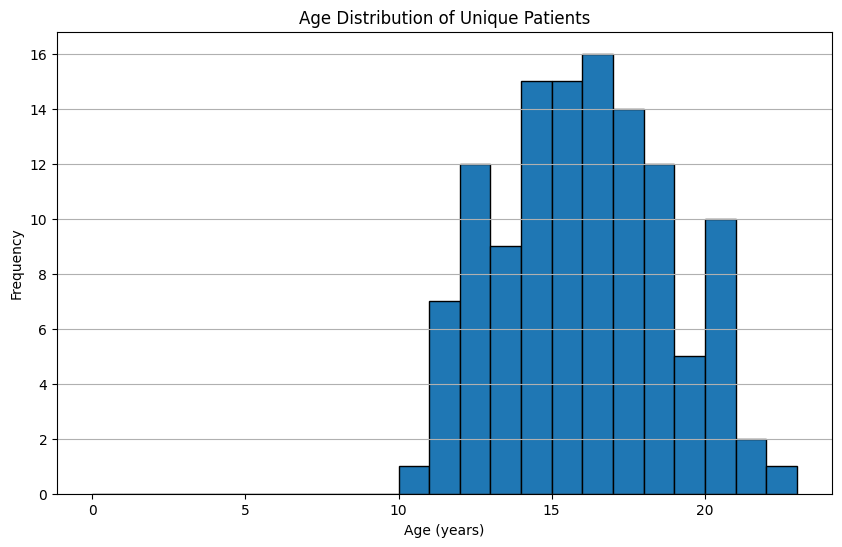

In [ ]:
# -----------------------------
# 18. What is the age distribution of patients
# -----------------------------

# # Calculate age distribution
age_distribution_counts = patient_data_excl_age['age'].value_counts().sort_index()
total_patients = len(patient_data_excl_age)
age_distribution_percentages = (age_distribution_counts / total_patients) * 100

# Ensure only unique patients are considered
unique_patients = patient_data_excl_age[['Participant Id', 'age']].drop_duplicates(subset='Participant Id')

# Calculate age distribution
age_distribution_counts = unique_patients['age'].value_counts().sort_index()
total_patients = len(unique_patients)
age_distribution_percentages = (age_distribution_counts / total_patients) * 100

print("\nAge Distribution (Counts):")
print(age_distribution_counts)
print("\nSum Age Distribution (Counts):")
print(sum(age_distribution_counts))


print("\nAge Distribution (Percentages):")
print(age_distribution_percentages)

# Plot histogram of age distribution using unique Patient IDs
plt.figure(figsize=(10, 6))
plt.hist(unique_patients['age'], bins=range(0, int(unique_patients['age'].max()) + 2), edgecolor='black')
plt.title('Age Distribution of Unique Patients')
plt.xlabel('Age (years)')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()


In [ ]:
# -----------------------------
# 19. What percentage of unique children with a raw vineland adaptive score between 85 and 115 are girls and how many are boys?
# -----------------------------

import pandas as pd
import re

# -----------------------------
# Data (fresh copies)
# -----------------------------
data_vineland = data_vineland_base.copy()
data_demographics = data_demographics_base.copy()

VINELAND_ADAPTIVE_RAW_COL = None

if VINELAND_ADAPTIVE_RAW_COL is None:
    candidates = [
        c for c in data_vineland.columns
        if re.search(r'(ada|adapt)', c, flags=re.IGNORECASE) and re.search(r'(ruw|raw)', c, flags=re.IGNORECASE)
    ]
    if not candidates:
        candidates = [c for c in data_vineland.columns if re.search(r'(ada|adapt)', c, flags=re.IGNORECASE)]
    VINELAND_ADAPTIVE_RAW_COL = candidates[0] if candidates else None

if VINELAND_ADAPTIVE_RAW_COL is None:
    raise KeyError("Could not infer the Vineland adaptive raw score column.")

# Ensure score is numeric
vineland_scores = data_vineland[['Participant Id', VINELAND_ADAPTIVE_RAW_COL]].drop_duplicates(subset='Participant Id').copy()
vineland_scores[VINELAND_ADAPTIVE_RAW_COL] = pd.to_numeric(vineland_scores[VINELAND_ADAPTIVE_RAW_COL], errors='coerce')

# Filter for raw scores between 85 and 115
filtered_scores = vineland_scores[
    (vineland_scores[VINELAND_ADAPTIVE_RAW_COL] >= 85) &
    (vineland_scores[VINELAND_ADAPTIVE_RAW_COL] <= 115)
].copy()

unique_patient_ids = filtered_scores['Participant Id'].dropna().unique()

dem = data_demographics[['Participant Id', 'dem_gender']].drop_duplicates(subset='Participant Id').copy()
relevant_patients = dem[dem['Participant Id'].isin(unique_patient_ids)].copy()

gender_counts = relevant_patients['dem_gender'].value_counts()
num_girls = int(gender_counts.get(0, 0))
num_boys = int(gender_counts.get(1, 0))
total = num_girls + num_boys

percentage_girls = (num_girls / total) * 100 if total > 0 else 0

print(f"Total unique children with raw score between 85 and 115: {total}")
print(f"Number of girls: {num_girls}")
print(f"Number of boys: {num_boys}")
print(f"Percentage of girls: {percentage_girls:.2f}%")


Total unique children with raw score between 85 and 115: 61
Number of girls: 16
Number of boys: 45
Percentage of girls: 26.23%


In [ ]:
# -----------------------------
# 20/ For  children who filled out the PROMs angst questionnaire, what percentage were female and what was the most common age for males?
# -----------------------------

# -----------------------------
# Data (fresh copies)
# -----------------------------
data_demographics = data_demographics_base.copy()
data_proms_angst = data_proms_angst_base.copy()

import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt


# --- Clean and prepare demographic data ---
data_demographics = data_demographics.dropna(subset=['dem_birth_month', 'dem_birth_year'])
data_demographics['dem_birth_month'] = pd.to_numeric(data_demographics['dem_birth_month'], errors='coerce')
data_demographics['dem_birth_year'] = pd.to_numeric(data_demographics['dem_birth_year'], errors='coerce')

# Create birth date and calculate age
data_demographics['birth_date'] = pd.to_datetime(
    data_demographics['dem_birth_year'].astype(int).astype(str) + '-' +
    data_demographics['dem_birth_month'].astype(int).astype(str) + '-01',
    errors='coerce'
)
data_demographics['age'] = (current_date - data_demographics['birth_date']).dt.days // 365
data_demographics = data_demographics.dropna(subset=['age'])

# --- Merge with PROMs Angst data ---
merged_data = pd.merge(
    data_demographics[['Participant Id', 'age', 'dem_gender']],
    data_proms_angst[['Participant Id', 'PROM_angst_Tscore']],
    on='Participant Id',
    how='left'
)

# --- Filter children who did NOT fill out the PROMs Angst questionnaire ---
children_without_proms = merged_data[merged_data['PROM_angst_Tscore'].isnull()]
unique_children_without_proms = children_without_proms[['Participant Id', 'age', 'dem_gender']].drop_duplicates(subset='Participant Id')

# --- Calculate percentage of females without promts ---
gender_counts = unique_children_without_proms['dem_gender'].value_counts()
total_children = gender_counts.sum()
female_percentage = (gender_counts.get(0, 0) / total_children) * 100
male_percentage = (gender_counts.get(1, 0) / total_children) * 100
other_percentage = (gender_counts.get(2, 0) / total_children) * 100

print(f"Percentage of females among children without PROMs Angst: {female_percentage:.2f}%, male: {male_percentage:.2f}, other: {other_percentage:.2f} ")

# --- Find most common age for males ---
male_data = unique_children_without_proms[unique_children_without_proms['dem_gender'] == 1]
most_common_age_males = male_data['age'].mode()

if not most_common_age_males.empty:
    print(f"Most common age for males: {most_common_age_males.iloc[0]} years")
else:
    print("No male data available to determine most common age.")


# --- Filter children who did NOT fill out the PROMs Angst questionnaire ---
children_with_proms = merged_data[merged_data['PROM_angst_Tscore'].notnull()]
unique_children_with_proms = children_with_proms[['Participant Id', 'age', 'dem_gender']].drop_duplicates(subset='Participant Id')

# --- Calculate percentage of females without promts ---
gender_counts = unique_children_with_proms['dem_gender'].value_counts()
total_children = gender_counts.sum()
female_percentage = (gender_counts.get(0, 0) / total_children) * 100
male_percentage = (gender_counts.get(1, 0) / total_children) * 100
other_percentage = (gender_counts.get(2, 0) / total_children) * 100

print(f"Percentage of females among children with PROMs Angst: {female_percentage:.2f}%, male: {male_percentage:.2f}, other: {other_percentage:.2f} ")

# --- Find most common age for males ---
male_data = unique_children_with_proms[unique_children_with_proms['dem_gender'] == 1]
most_common_age_males = male_data['age'].mode()

if not most_common_age_males.empty:
    print(f"Most common age for males: {most_common_age_males.iloc[0]} years")
else:
    print("No male data available to determine most common age.")


Percentage of females among children without PROMs Angst: 50.00%, male: 50.00, other: 0.00 
Most common age for males: 16 years
Percentage of females among children with PROMs Angst: 35.34%, male: 63.79, other: 0.86 
Most common age for males: 17 years


Diagnosis

In [ ]:
# -----------------------------
# 21. How many patients are in my dataset:
# -----------------------------

print(f"There are 116 children in my dataset")


There are 119 children in my dataset


In [ ]:
# -----------------------------
# 22. How many patients have autism
# -----------------------------

print(f"There are 105 children in my dataset with autism")


There are 105 children in my dataset with autism


In [ ]:
# -----------------------------
# 23. What percentage of children had their PROMs filled out by their father only?
# -----------------------------
## Note: Check this manually in your dataset, to ensure you cover any potential semantic mismatches.
import pandas as pd
import re

# -----------------------------
# Data (fresh copies)
# -----------------------------
data_proms_angst = data_proms_angst_base.copy()
data_proms_cognitief_functioneren = data_proms_cognitief_functioneren_base.copy()
data_proms_depression = data_proms_depression_base.copy()
data_proms_fatigue = data_proms_fatigue_base.copy()

def _infer_pid_col(df: pd.DataFrame):
    for col in ['Participant Id', 'subject.reference', 'id']:
        if col in df.columns:
            return col
    return None

def _infer_author_col(df: pd.DataFrame):
    # direct hits first
    for col in ['author.display', 'author', 'Author', 'author_display', 'authorDisplay', 'respondent', 'invuller']:
        if col in df.columns:
            return col
    # fallback: any column that looks like an author/respondent field
    candidates = [c for c in df.columns if re.search(r'(author|invuller|respondent|performer)', c, flags=re.IGNORECASE)]
    return candidates[0] if candidates else None

def _normalize_pid(s: pd.Series) -> pd.Series:
    return s.astype(str).str.replace('Patient/', '', regex=False).str.strip()

prom_dfs = [
    ('PROM_angst', data_proms_angst),
    ('PROM_cognitief_functioneren', data_proms_cognitief_functioneren),
    ('PROM_depressieve_klachten', data_proms_depression),
    ('PROM_vermoeidheid', data_proms_fatigue),
]

patient_authors = {}
has_prom = {}

for name, df in prom_dfs:
    pid_col = _infer_pid_col(df)
    author_col = _infer_author_col(df)

    if pid_col is None or author_col is None:
        print(f"Skipping {name} (missing id/author columns)")
        continue

    tmp = df[[pid_col, author_col]].copy()
    tmp['pid'] = _normalize_pid(tmp[pid_col])
    tmp['author_norm'] = tmp[author_col].fillna('').astype(str).str.strip()

    for pid, authors in tmp.groupby('pid')['author_norm']:
        if pid not in patient_authors:
            patient_authors[pid] = set()
            has_prom[pid] = False
        has_prom[pid] = True
        patient_authors[pid].update(authors.unique())

all_patients = set(patient_authors.keys())
n_total = len(all_patients)

father_only = [p for p, a in patient_authors.items() if has_prom[p] and a == {'Father', 'Vader'}]
pct_father_only = (len(father_only) / n_total) * 100 if n_total > 0 else 0

print("\nResults:")
print(f"Total patients with any PROM: {n_total}")
print(f"Patients with PROMs by Father ONLY: {len(father_only)} ({pct_father_only:.1f}%)")

# Optional: Preview author mixes
preview = [(pid, sorted(list(authors))) for pid, authors in list(patient_authors.items())[:10]]
print("\nSample author mixes:")
for pid, authors in preview:
    print(f"{pid}: {authors}")



Results:
Total patients with any PROM: 119
Patients with PROMs by Father ONLY: 4 (3.4%)

Sample author mixes:
Patient/BU001: ['', 'Father', 'Mother']
Patient/BU002: ['Mother']
Patient/BU003: ['Mother']
Patient/BU005: ['Father', 'Father and Mother', 'Mother']
Patient/BU006: ['Mother']
Patient/BU007: ['Father', 'Mother']
Patient/BU008: ['Mother']
Patient/BU010: ['Mother']
Patient/BU011: ['Mother']
Patient/BU014: ['Mother']


In [ ]:
# -----------------------------
# 24. What percentage of children that have autism had their PROMs filled out by their mother only?
# -----------------------------
## Note: Check this manually in your dataset, to ensure you cover any potential semantic mismatches.
import pandas as pd
import re

# -----------------------------
# Data (fresh copies)
# -----------------------------
data_neuropsychiatric_history = data_neuropsychiatric_history_base.copy()
data_proms_angst = data_proms_angst_base.copy()
data_proms_cognitief_functioneren = data_proms_cognitief_functioneren_base.copy()
data_proms_depression = data_proms_depression_base.copy()
data_proms_fatigue = data_proms_fatigue_base.copy()

def _infer_pid_col(df: pd.DataFrame):
    for col in ['Participant Id', 'subject.reference', 'id']:
        if col in df.columns:
            return col
    return None

def _normalize_pid(s: pd.Series) -> pd.Series:
    return s.astype(str).str.replace('Patient/', '', regex=False).str.strip()

def _infer_author_col(df: pd.DataFrame):
    for col in ['author.display', 'author', 'Author', 'author_display', 'authorDisplay', 'respondent', 'invuller']:
        if col in df.columns:
            return col
    candidates = [c for c in df.columns if re.search(r'(author|invuller|respondent|performer)', c, flags=re.IGNORECASE)]
    return candidates[0] if candidates else None

def _infer_autism_patients(neuro: pd.DataFrame):
    pid_col = _infer_pid_col(neuro)
    if pid_col is None:
        raise KeyError("Could not infer patient id column in neuropsychiatric history.")

    # Prefer explicit autism column if present
    autism_cols = [c for c in neuro.columns if re.search(r'autism', c, flags=re.IGNORECASE)]
    if autism_cols:
        col = autism_cols[0]
        s = neuro[col]
        if pd.api.types.is_bool_dtype(s):
            mask = s.fillna(False)
        elif pd.api.types.is_numeric_dtype(s):
            mask = s.fillna(0) != 0
        else:
            mask = s.astype(str).str.lower().str.contains('autism', na=False)
        return set(_normalize_pid(neuro.loc[mask, pid_col].dropna().unique()))

    # Fallback: search string columns for 'autism'
    obj_cols = neuro.select_dtypes(include='object').columns
    if len(obj_cols) == 0:
        return set()

    mask = neuro[obj_cols].astype(str).apply(lambda col: col.str.lower().str.contains('autism', na=False)).any(axis=1)
    return set(_normalize_pid(neuro.loc[mask, pid_col].dropna().unique()))

AUT = _infer_autism_patients(data_neuropsychiatric_history)
print(f"Total autism patients: {len(AUT)}")

prom_dfs = [
    ('PROM_angst', data_proms_angst),
    ('PROM_cognitief_functioneren', data_proms_cognitief_functioneren),
    ('PROM_depressieve_klachten', data_proms_depression),
    ('PROM_vermoeidheid', data_proms_fatigue),
]

patient_authors = {p: set() for p in AUT}
has_prom = {p: False for p in AUT}

for name, df in prom_dfs:
    pid_col = _infer_pid_col(df)
    author_col = _infer_author_col(df)

    if pid_col is None or author_col is None:
        print(f"Skipping {name} (missing id/author columns)")
        continue

    tmp = df[[pid_col, author_col]].copy()
    tmp['pid'] = _normalize_pid(tmp[pid_col])
    tmp = tmp[tmp['pid'].isin(AUT)].copy()
    if tmp.empty:
        continue

    tmp['author_norm'] = tmp[author_col].fillna('').astype(str).str.strip()

    for pid, authors in tmp.groupby('pid')['author_norm']:
        has_prom[pid] = True
        patient_authors[pid].update(authors.unique())

n_autism = len(AUT)
any_mother = [p for p, a in patient_authors.items() if 'Mother' in a]
mother_only = [p for p, a in patient_authors.items() if has_prom[p] and a == {'Mother', 'Moeder'}]

pct_any_mother = (len(any_mother) / n_autism) * 100 if n_autism > 0 else 0
pct_mother_only = (len(mother_only) / n_autism) * 100 if n_autism > 0 else 0

print("\nResults:")
print(f"Autism patients: {n_autism}")
print(f"Patients with any PROM by Mother: {len(any_mother)} ({pct_any_mother:.1f}%)")
print(f"Patients with PROMs by Mother ONLY: {len(mother_only)} ({pct_mother_only:.1f}%)")

preview = [(pid, sorted(list(authors))) for pid, authors in list(patient_authors.items())[:10]]
print("\nSample author mixes:")
for pid, authors in preview:
    print(f"{pid}: {authors}")


Total autism patients: 105

Results:
Autism patients: 105
Patients with any PROM by Mother: 93 (88.6%)
Patients with PROMs by Mother ONLY: 55 (52.4%)

Sample author mixes:
Patient/BU034: ['Mother']
Patient/BU167: ['Father', 'Mother']
Patient/BU044: ['Father', 'Father and Mother', 'Mother']
Patient/BU182: ['Father', 'Mother']
Patient/BU067: ['Father', 'Mother']
Patient/BU005: ['Father', 'Father and Mother', 'Mother']
Patient/BU065: ['Father', 'Mother']
Patient/BU082: ['Father', 'Mother']
Patient/BU165: ['Mother']
Patient/BU126: ['Mother']


In [ ]:
# -----------------------------
# 25. What percentage of children that have autism had either PROMs, RBS or SRS filled out by their father?
# -----------------------------

import pandas as pd
import re

# -----------------------------
# Data (fresh copies)
# -----------------------------
data_neuropsychiatric_history = data_neuropsychiatric_history_base.copy()
data_proms_angst = data_proms_angst_base.copy()
data_proms_cognitief_functioneren = data_proms_cognitief_functioneren_base.copy()
data_proms_depression = data_proms_depression_base.copy()
data_proms_fatigue = data_proms_fatigue_base.copy()
data_rbs = data_rbs_base.copy()
data_srs = data_srs_base.copy()

def _infer_pid_col(df: pd.DataFrame):
    for col in ['Participant Id', 'subject.reference', 'id']:
        if col in df.columns:
            return col
    return None

def _normalize_pid(s: pd.Series) -> pd.Series:
    return s.astype(str).str.replace('Patient/', '', regex=False).str.strip()

def _infer_author_like_col(df: pd.DataFrame):
    # direct hits first
    for col in ['author.display', 'author', 'Author', 'author_display', 'authorDisplay', 'respondent', 'invuller', 'performer.reference', 'performer.display']:
        if col in df.columns:
            return col
    candidates = [c for c in df.columns if re.search(r'(author|invuller|respondent|performer)', c, flags=re.IGNORECASE)]
    return candidates[0] if candidates else None

def _infer_autism_patients(neuro: pd.DataFrame):
    pid_col = _infer_pid_col(neuro)
    if pid_col is None:
        raise KeyError("Could not infer patient id column in neuropsychiatric history.")

    autism_cols = [c for c in neuro.columns if re.search(r'autism', c, flags=re.IGNORECASE)]
    if autism_cols:
        col = autism_cols[0]
        s = neuro[col]
        if pd.api.types.is_bool_dtype(s):
            mask = s.fillna(False)
        elif pd.api.types.is_numeric_dtype(s):
            mask = s.fillna(0) != 0
        else:
            mask = s.astype(str).str.lower().str.contains('autism', na=False)
        return set(_normalize_pid(neuro.loc[mask, pid_col].dropna().unique()))

    obj_cols = neuro.select_dtypes(include='object').columns
    if len(obj_cols) == 0:
        return set()

    mask = neuro[obj_cols].astype(str).apply(lambda col: col.str.lower().str.contains('autism', na=False)).any(axis=1)
    return set(_normalize_pid(neuro.loc[mask, pid_col].dropna().unique()))

autism_patients = _infer_autism_patients(data_neuropsychiatric_history)

# Track father involvement
father_involved = {pid: False for pid in autism_patients}

# --- PROM files ---
prom_dfs = [
    ('PROM_angst', data_proms_angst),
    ('PROM_cognitief_functioneren', data_proms_cognitief_functioneren),
    ('PROM_depressieve_klachten', data_proms_depression),
    ('PROM_vermoeidheid', data_proms_fatigue),
]

for name, df in prom_dfs:
    pid_col = _infer_pid_col(df)
    author_col = _infer_author_like_col(df)
    if pid_col is None or author_col is None:
        print(f"Skipping {name} (missing id/author columns)")
        continue

    tmp = df[[pid_col, author_col]].copy()
    tmp['pid'] = _normalize_pid(tmp[pid_col])
    tmp = tmp[tmp['pid'].isin(autism_patients)].copy()
    if tmp.empty:
        continue

    tmp['author_norm'] = tmp[author_col].fillna('').astype(str).str.strip()
    for pid, authors in tmp.groupby('pid')['author_norm']:
        if (authors == 'Father').any():
            father_involved[pid] = True

# --- RBS ---
pid_col = _infer_pid_col(data_rbs)
author_col = _infer_author_like_col(data_rbs)
if pid_col is not None and author_col is not None:
    tmp = data_rbs[[pid_col, author_col]].copy()
    tmp['pid'] = _normalize_pid(tmp[pid_col])
    tmp = tmp[tmp['pid'].isin(autism_patients)].copy()
    tmp['author_norm'] = tmp[author_col].fillna('').astype(str).str.strip()
    for pid, authors in tmp.groupby('pid')['author_norm']:
        if (authors == 'Father').any():
            father_involved[pid] = True
else:
    print("Skipping RBS (missing id/author columns)")

# --- SRS ---
pid_col = _infer_pid_col(data_srs)
author_col = _infer_author_like_col(data_srs)
if pid_col is not None and author_col is not None:
    tmp = data_srs[[pid_col, author_col]].copy()
    tmp['pid'] = _normalize_pid(tmp[pid_col])
    tmp = tmp[tmp['pid'].isin(autism_patients)].copy()
    tmp['author_norm'] = tmp[author_col].fillna('').astype(str).str.strip()
    for pid, authors in tmp.groupby('pid')['author_norm']:
        if (authors == 'Father').any():
            father_involved[pid] = True
else:
    print("Skipping SRS (missing id/author columns)")

total_autism = len(autism_patients)
father_count = sum(father_involved.values())
percentage = (father_count / total_autism * 100) if total_autism > 0 else 0

print(f"Total children with autism: {total_autism}")
print(f"Children with at least one questionnaire filled out by father: {father_count}")
print(f"Percentage: {percentage:.2f}%")


Total children with autism: 105
Children with at least one questionnaire filled out by father: 46
Percentage: 43.81%
